In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

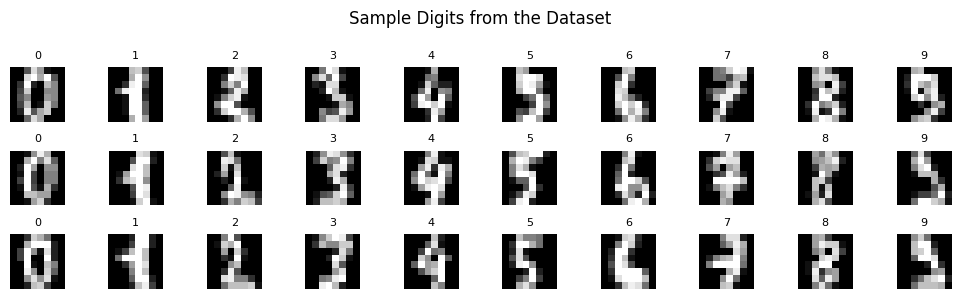

In [ ]:
# ---------------------------
# 1) Load data
# ---------------------------
digits = load_digits()          # offline-safe sample dataset (1797 samples, 64 features)
X = digits.data                # shape (n_samples, n_features)
y = digits.target              # integer labels 0..9

fig, axes = plt.subplots(3, 10, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')
    ax.set_title(y[i], fontsize=8)
    ax.axis('off')
plt.suptitle("Sample Digits from the Dataset", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
print("Loaded data shape:", X.shape)

Loaded data shape: (1797, 64)


In [ ]:
# ---------------------------
# 2) Standardize features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# ---------------------------
# 3) PCA (recommended)
#    - speeds up t-SNE and removes noise
#    - for MNIST, 50 dims is common
# ---------------------------
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("After PCA:", X_pca.shape)

After PCA: (1797, 50)


In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    n_iter=5000,
    random_state=42,
    learning_rate='auto'
)
X_tsne = tsne.fit_transform(X_pca)
print("t-SNE output shape:", X_tsne.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE output shape: (1797, 2)


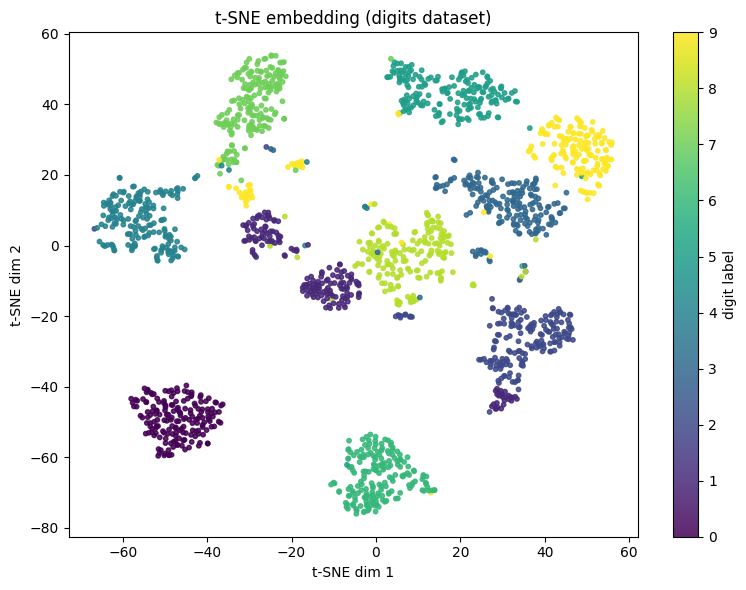

In [ ]:
# ---------------------------
# 5) Plot t-SNE embedding
# ---------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, s=10, alpha=0.85)
plt.title("t-SNE embedding (digits dataset)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.colorbar(label='digit label')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


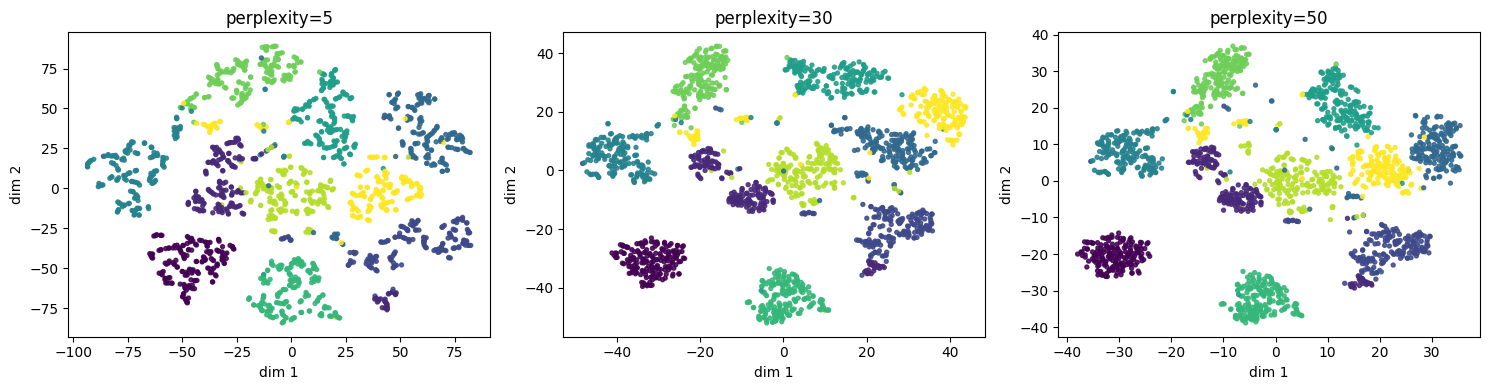

In [ ]:
# ---------------------------
# 6) Compare perplexities
# ---------------------------
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(15,4))
for ax, perp in zip(axes, perplexities):
    tsne_tmp = TSNE(n_components=2, perplexity=perp, init='pca', n_iter=1000, random_state=42, learning_rate='auto')
    X_tmp = tsne_tmp.fit_transform(X_pca)
    ax.scatter(X_tmp[:,0], X_tmp[:,1], c=y, s=8, alpha=0.85)
    ax.set_title(f"perplexity={perp}")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
plt.tight_layout()
plt.show()

In [ ]:
# PCA (for both visualization and preprocessing)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, init='pca', n_iter=1000, random_state=42, learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


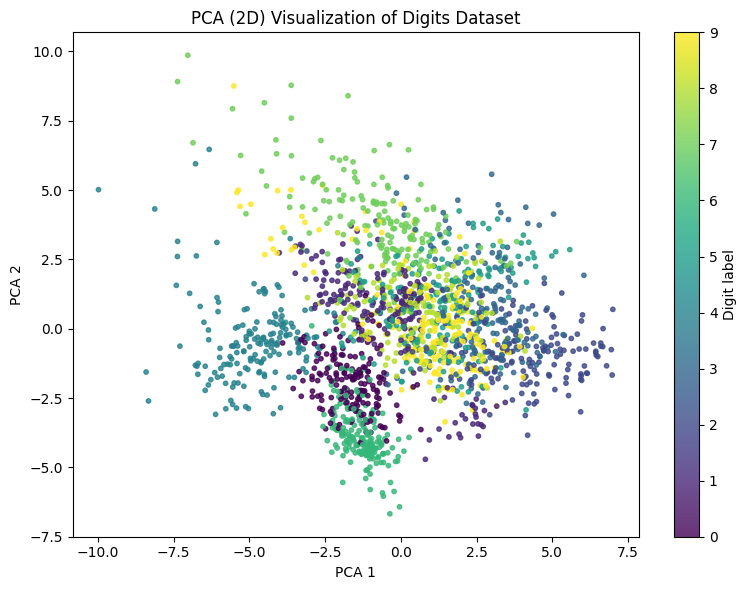

In [ ]:
pca_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(pca_2d[:,0], pca_2d[:,1], c=y, s=10, alpha=0.8)
plt.title("PCA (2D) Visualization of Digits Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label='Digit label')
plt.tight_layout()
plt.show()

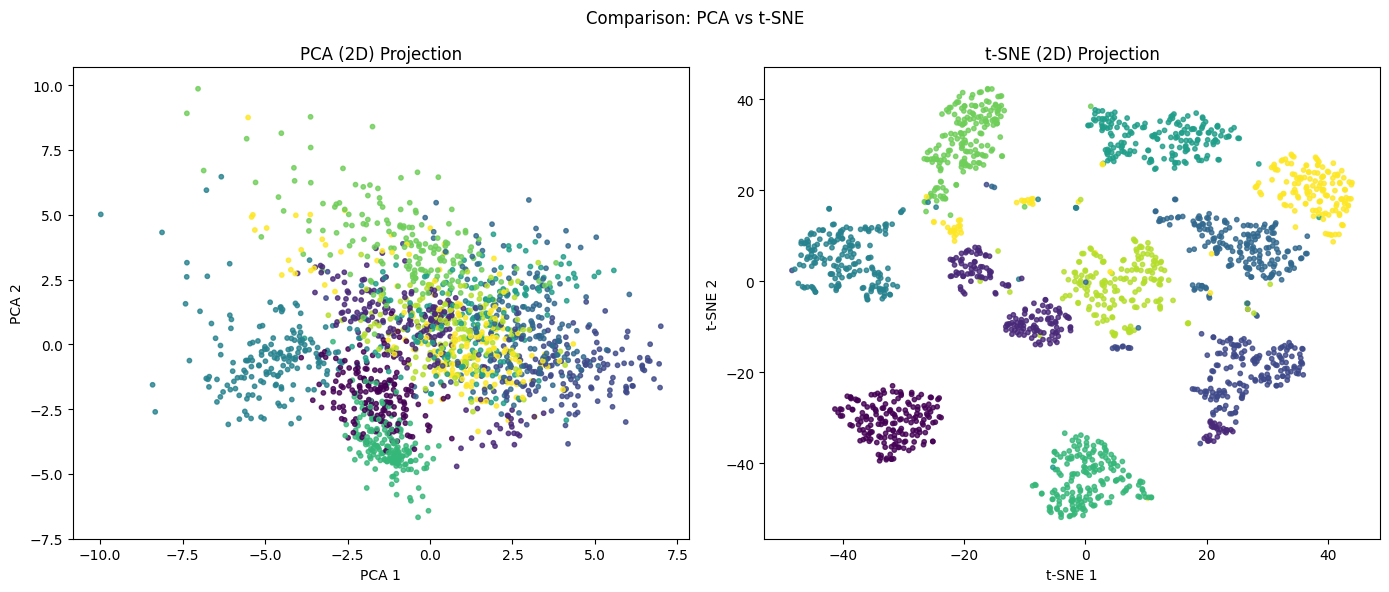

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].scatter(pca_2d[:,0], pca_2d[:,1], c=y, s=10, alpha=0.8)
axes[0].set_title("PCA (2D) Projection")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y, s=10, alpha=0.8)
axes[1].set_title("t-SNE (2D) Projection")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.suptitle("Comparison: PCA vs t-SNE")
plt.tight_layout()
plt.show()